## PTQ & QAT result plots

All plots read from the averaged CSVs in `resultsv2/final/`.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path

plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.dpi"] = 150

PROJECT_ROOT = Path("..").resolve()
FINAL_DIR = PROJECT_ROOT / "resultsv2" / "final"

avg_ptq = pd.read_csv(FINAL_DIR / "avg_ptq.csv")
avg_qat = pd.read_csv(FINAL_DIR / "avg_qat.csv")

COLS = 2
eb_kw = dict(capsize=3, capthick=0.8, elinewidth=0.8, linewidth=0)

BIT_PALETTE = {1: "#002B45", 2: "#009681", 4: "#239ED7", 8: "#8DB23E"}

PREC_PALETTE = {
    "fp32": "#002B45", "fp16": "#239ED7", "fp8": "#009681",
    "int8": "#8DB23E", "int4": "#0E4B75",
    "qat_int8": "#D62728", "qat_int4": "#FF7F0E",
}

QAT_PALETTE = {
    "qat_int8": "#009681", "qat_int4": "#FF7F0E",
    "int8": "#0E4B75", "int4": "#002B45",
}

def make_figure(title, n):
    nrows = math.ceil(n / COLS)
    fig, axes = plt.subplots(nrows, COLS, figsize=(4.5 * COLS, 3.8 * nrows),
                             constrained_layout=True, squeeze=False)
    fig.suptitle(title, fontsize=12, fontweight="normal",
                 x=0.5, ha="center", y=1.04)
    fig.set_constrained_layout_pads(wspace=0.15, hspace=0.1)
    ax_flat = axes.flatten()
    for idx in range(n, len(ax_flat)):
        ax_flat[idx].set_visible(False)
    return ax_flat

### PTQ latency by precision

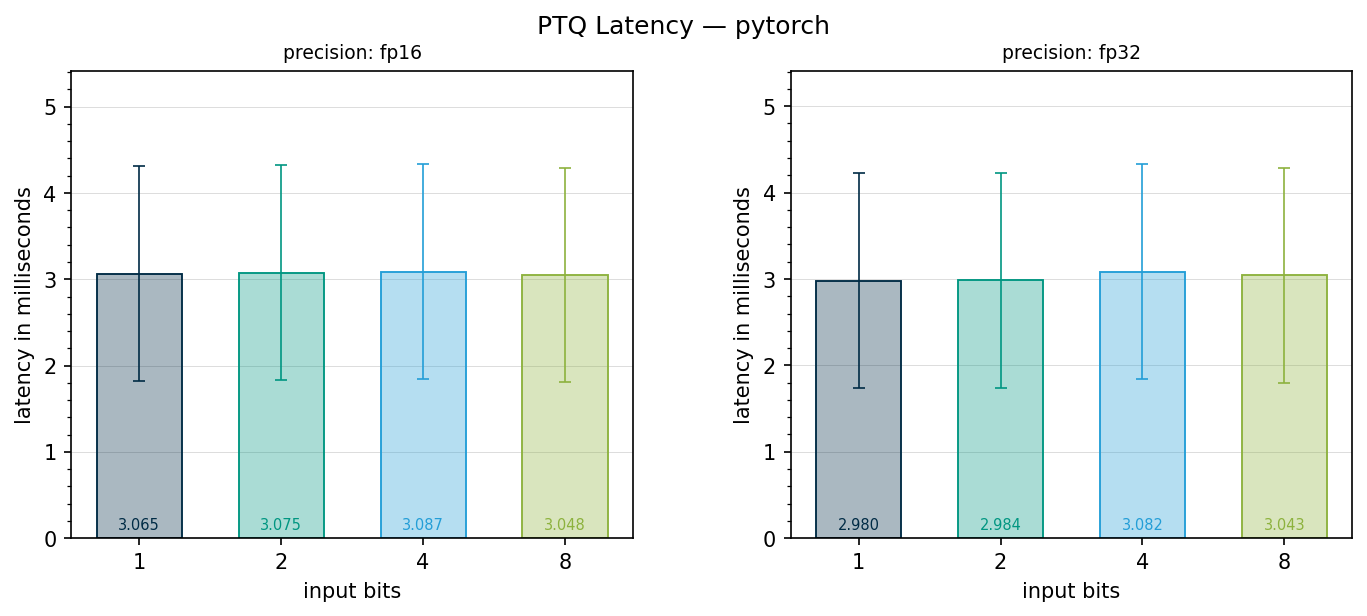

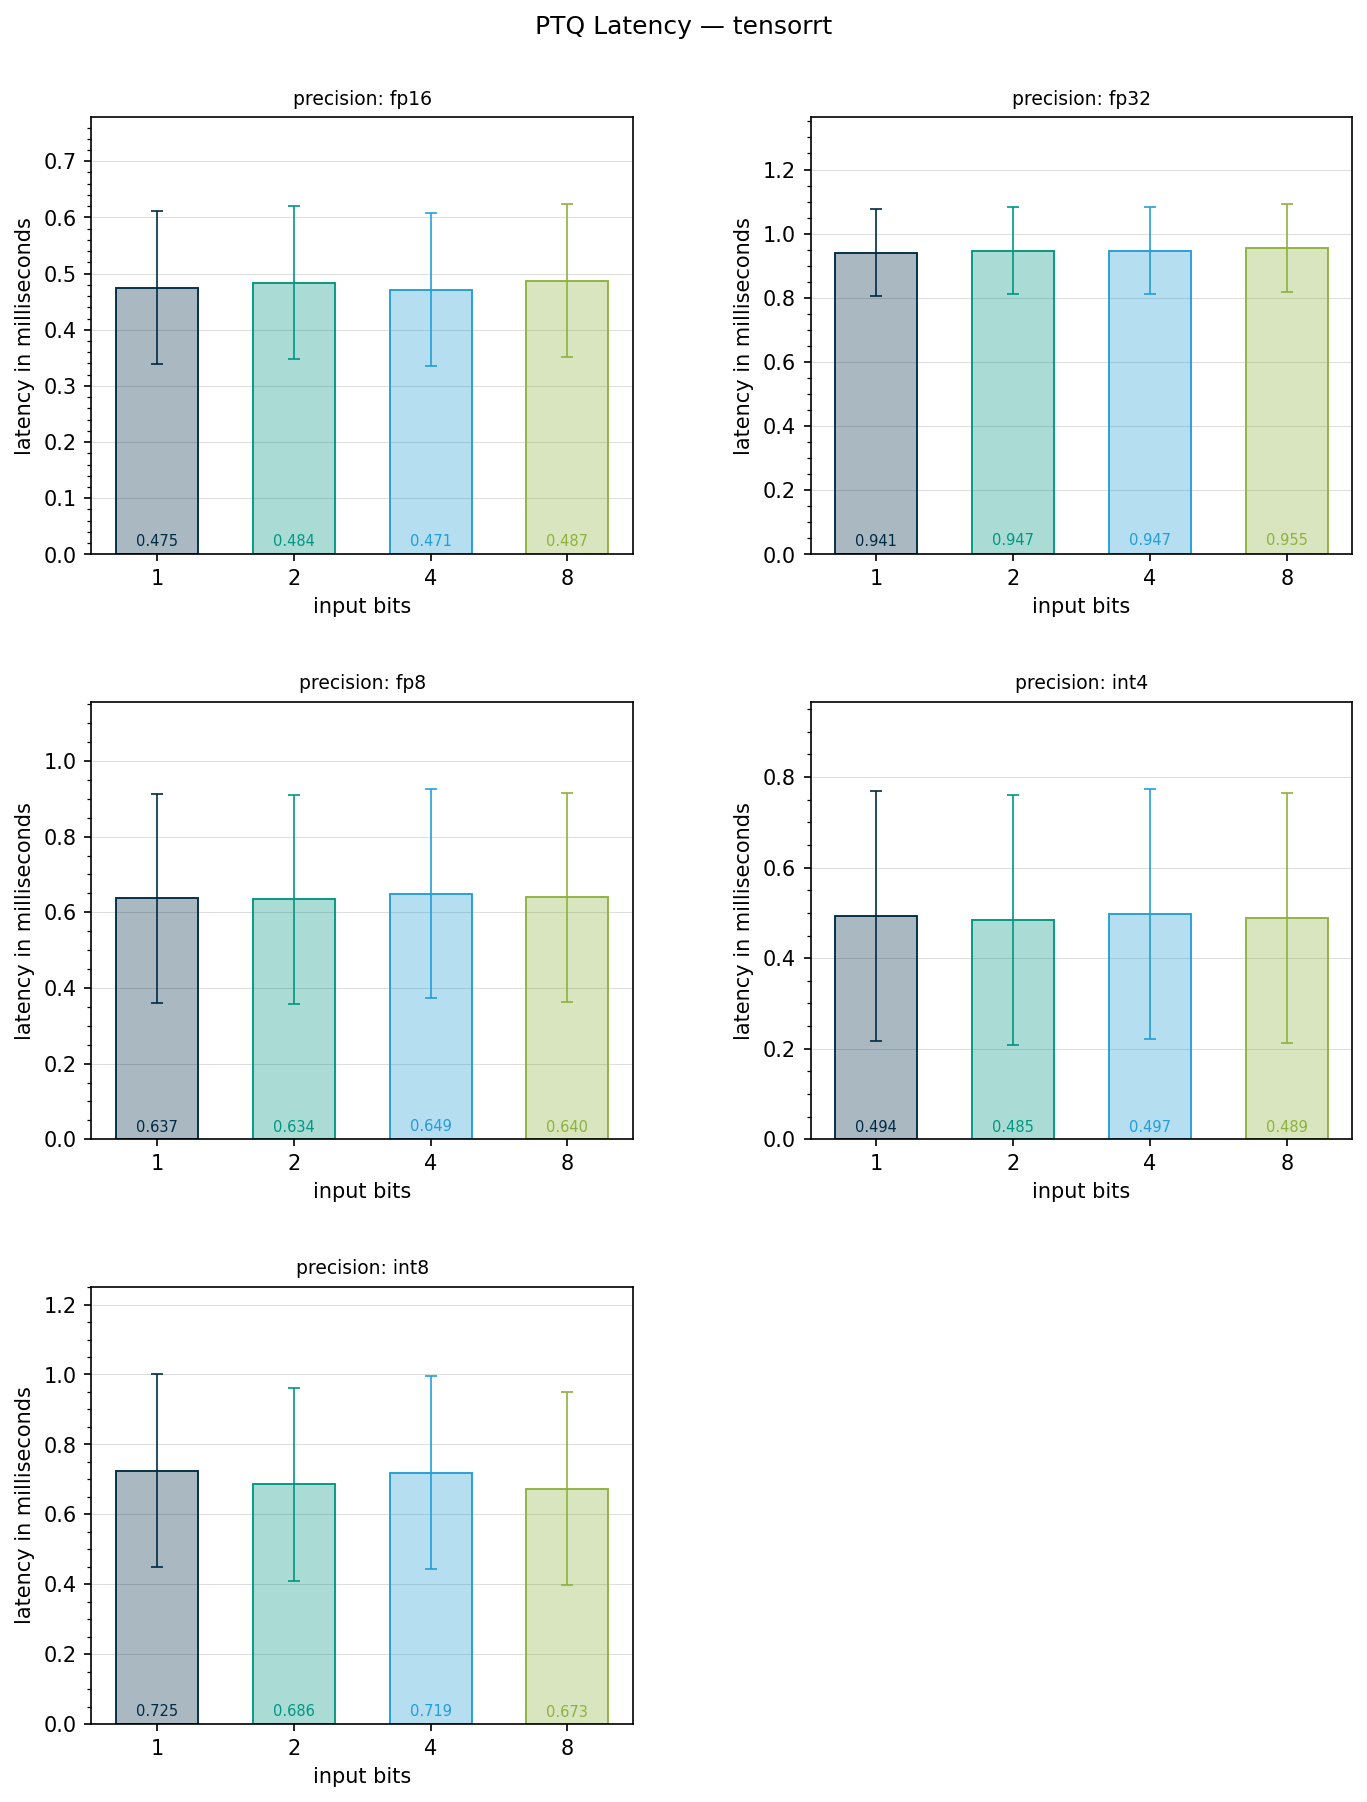

In [2]:
BACKENDS = ["pytorch", "tensorrt"]
for backend in BACKENDS:
    backend_data = avg_ptq[avg_ptq["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(f"PTQ Latency — {backend}", n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = backend_data[backend_data["precision"] == prec].sort_values("input_bits").reset_index(drop=True)
        if grp.empty:
            continue

        x_vals = grp["input_bits"].astype(int).tolist()
        x_pos = np.arange(len(x_vals))

        for xi, (_, row) in enumerate(grp.iterrows()):
            bits = int(row["input_bits"])
            c = BIT_PALETTE.get(bits, "#7f7f7f")
            ax.bar(xi, row["latency_ms"], color=c + "55", edgecolor=c,
                   linewidth=0.9, width=0.6, zorder=2)
            ax.errorbar(xi, row["latency_ms"], yerr=row["latency_std"],
                        fmt="none", ecolor=c, **eb_kw)
            ax.text(xi, row["latency_ms"] * 0.02, f"{row['latency_ms']:.3f}",
                    ha="center", va="bottom", fontsize=7, color=c, zorder=3)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(v) for v in x_vals])
        ax.set_ylim(0, (grp["latency_ms"] + grp["latency_std"]).max() * 1.25)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
        ax.set_xlabel("input bits")
        ax.set_ylabel("latency in milliseconds")
        ax.set_title(f"precision: {prec}", fontsize=9)

    plt.show()

### PTQ accuracy by precision

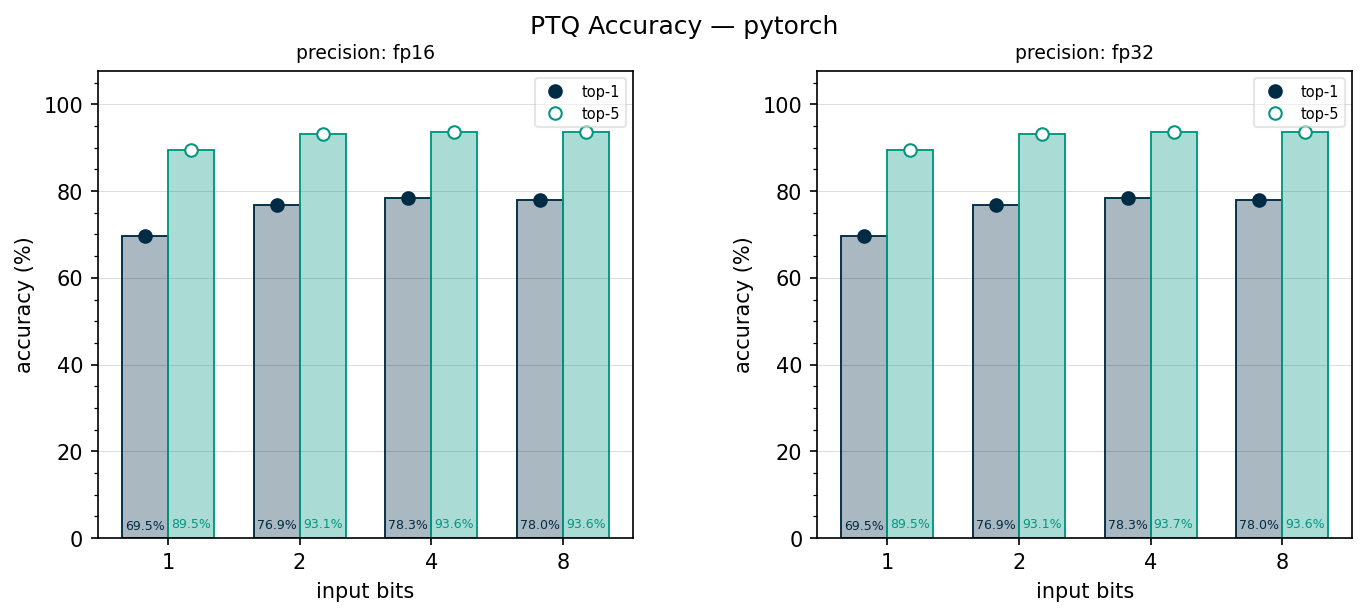

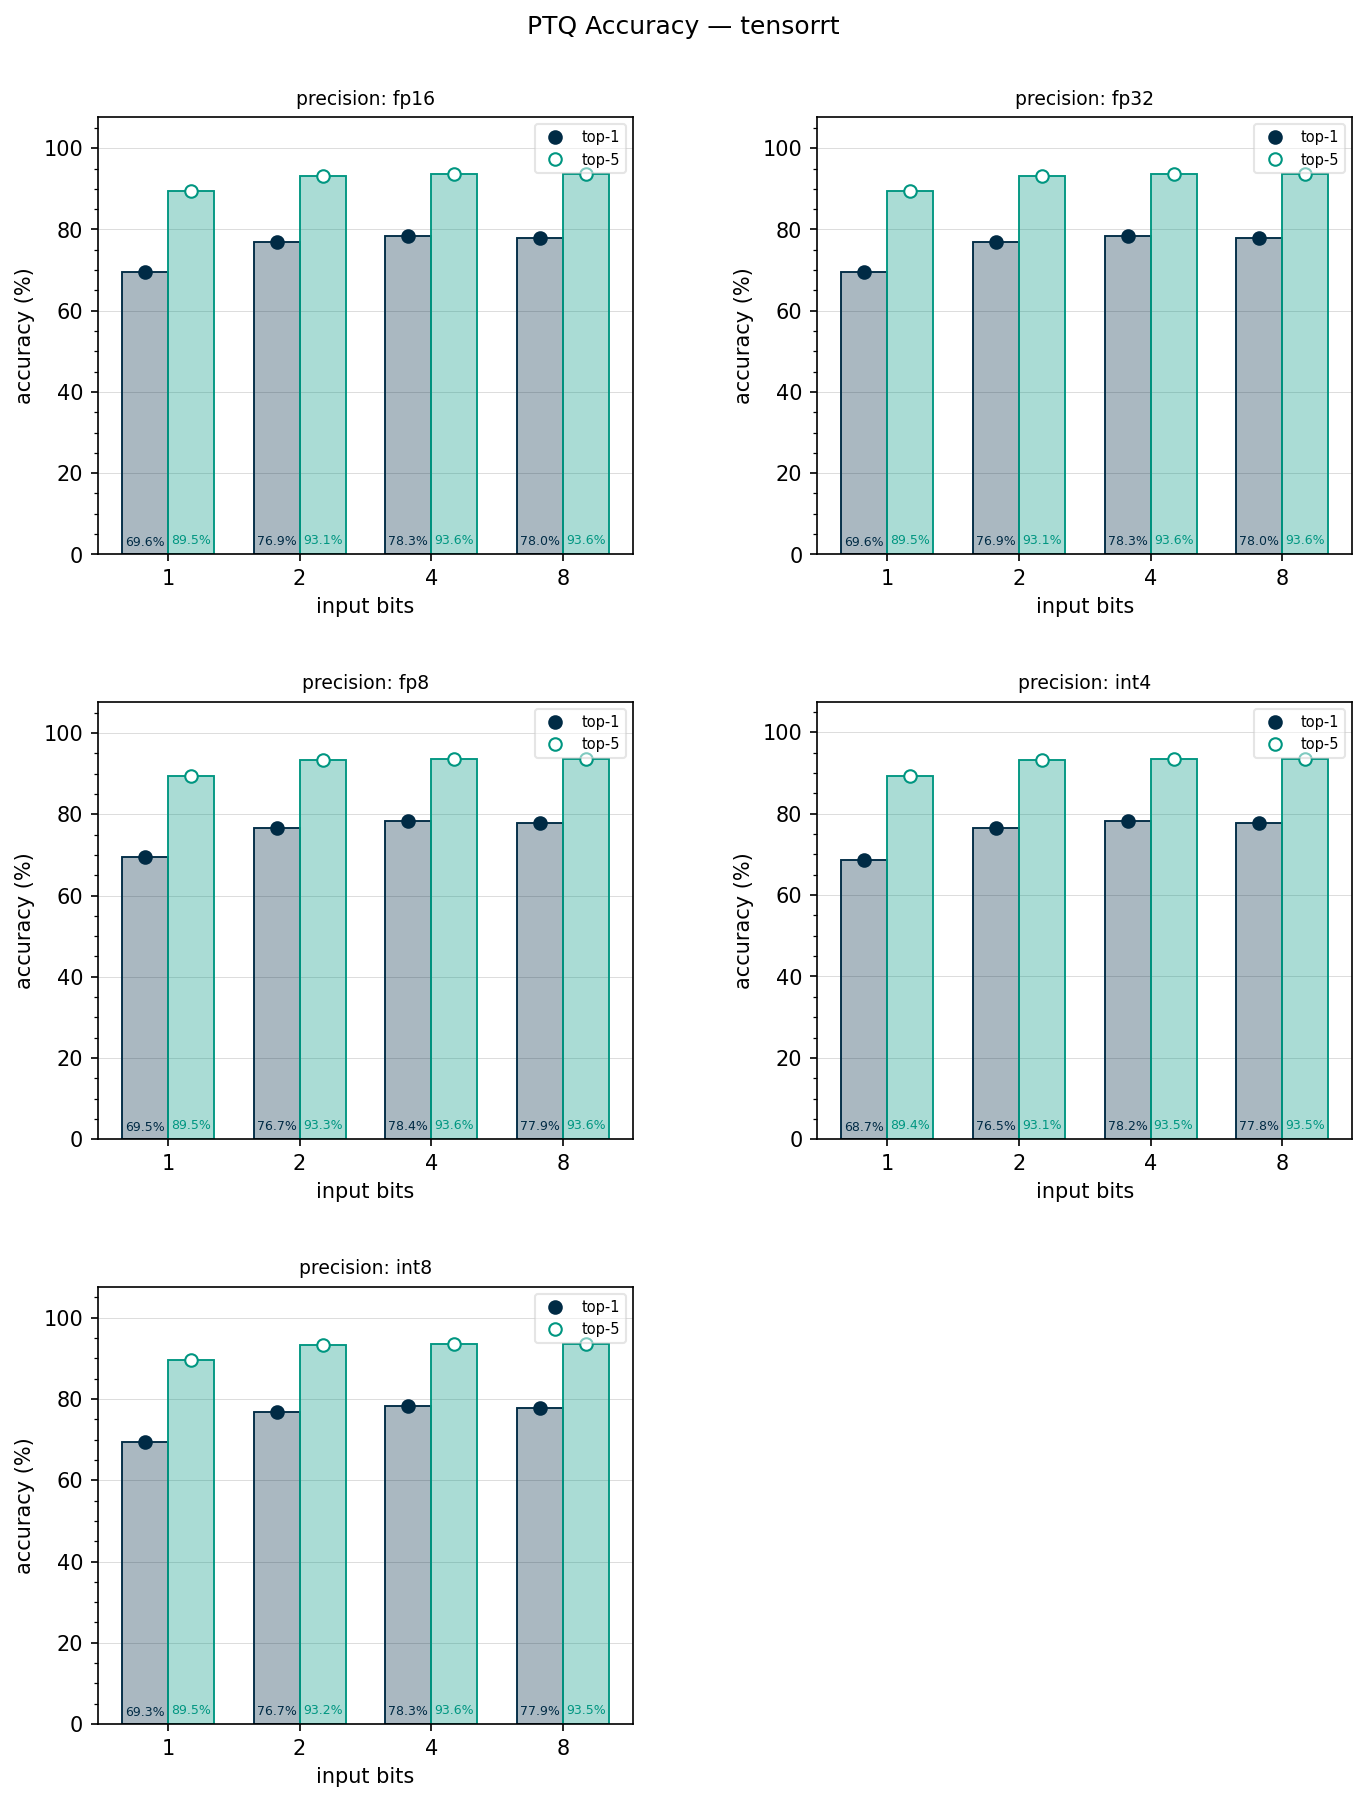

In [3]:
for backend in BACKENDS:
    backend_data = avg_ptq[avg_ptq["backend"] == backend]
    active_precisions = sorted(backend_data["precision"].unique())
    n = len(active_precisions)
    if n == 0:
        continue

    ax_flat = make_figure(f"PTQ Accuracy — {backend}", n)

    for ax, prec in zip(ax_flat, active_precisions):
        grp = backend_data[backend_data["precision"] == prec].sort_values("input_bits").reset_index(drop=True)
        if grp.empty:
            continue

        bits = grp["input_bits"].astype(int).tolist()
        x_pos = np.arange(len(bits))
        width = 0.35

        ax.bar(x_pos - width / 2, grp["top1"], width=width,
               color="#002B4555", edgecolor="#002B45", linewidth=0.9, zorder=2)
        ax.bar(x_pos + width / 2, grp["top5"], width=width,
               color="#00968155", edgecolor="#009681", linewidth=0.9, zorder=2)

        ax.plot(x_pos - width / 2, grp["top1"], color="#002B45",
                marker="o", linestyle="none", markersize=6, label="top-1", zorder=3)
        ax.plot(x_pos + width / 2, grp["top5"], color="#009681",
                marker="o", linestyle="none", markersize=6,
                markerfacecolor="white", label="top-5", zorder=3)

        for xi, (_, row) in enumerate(grp.iterrows()):
            ax.text(xi - width / 2, row["top1"] * 0.02, f"{row['top1']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#002B45", zorder=4)
            ax.text(xi + width / 2, row["top5"] * 0.02, f"{row['top5']:.1f}%",
                    ha="center", va="bottom", fontsize=6, color="#009681", zorder=4)

        ax.set_xticks(x_pos)
        ax.set_xticklabels([str(b) for b in bits])
        ax.set_xlabel("input bits")
        ax.set_ylabel("accuracy (%)")
        ax.set_title(f"precision: {prec}", fontsize=9)
        ax.set_ylim(0, grp[["top1", "top5"]].max().max() * 1.15)
        ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
        ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)
        ax.legend(fontsize=7, framealpha=0.5)

    plt.show()

### Accuracy vs latency scatter

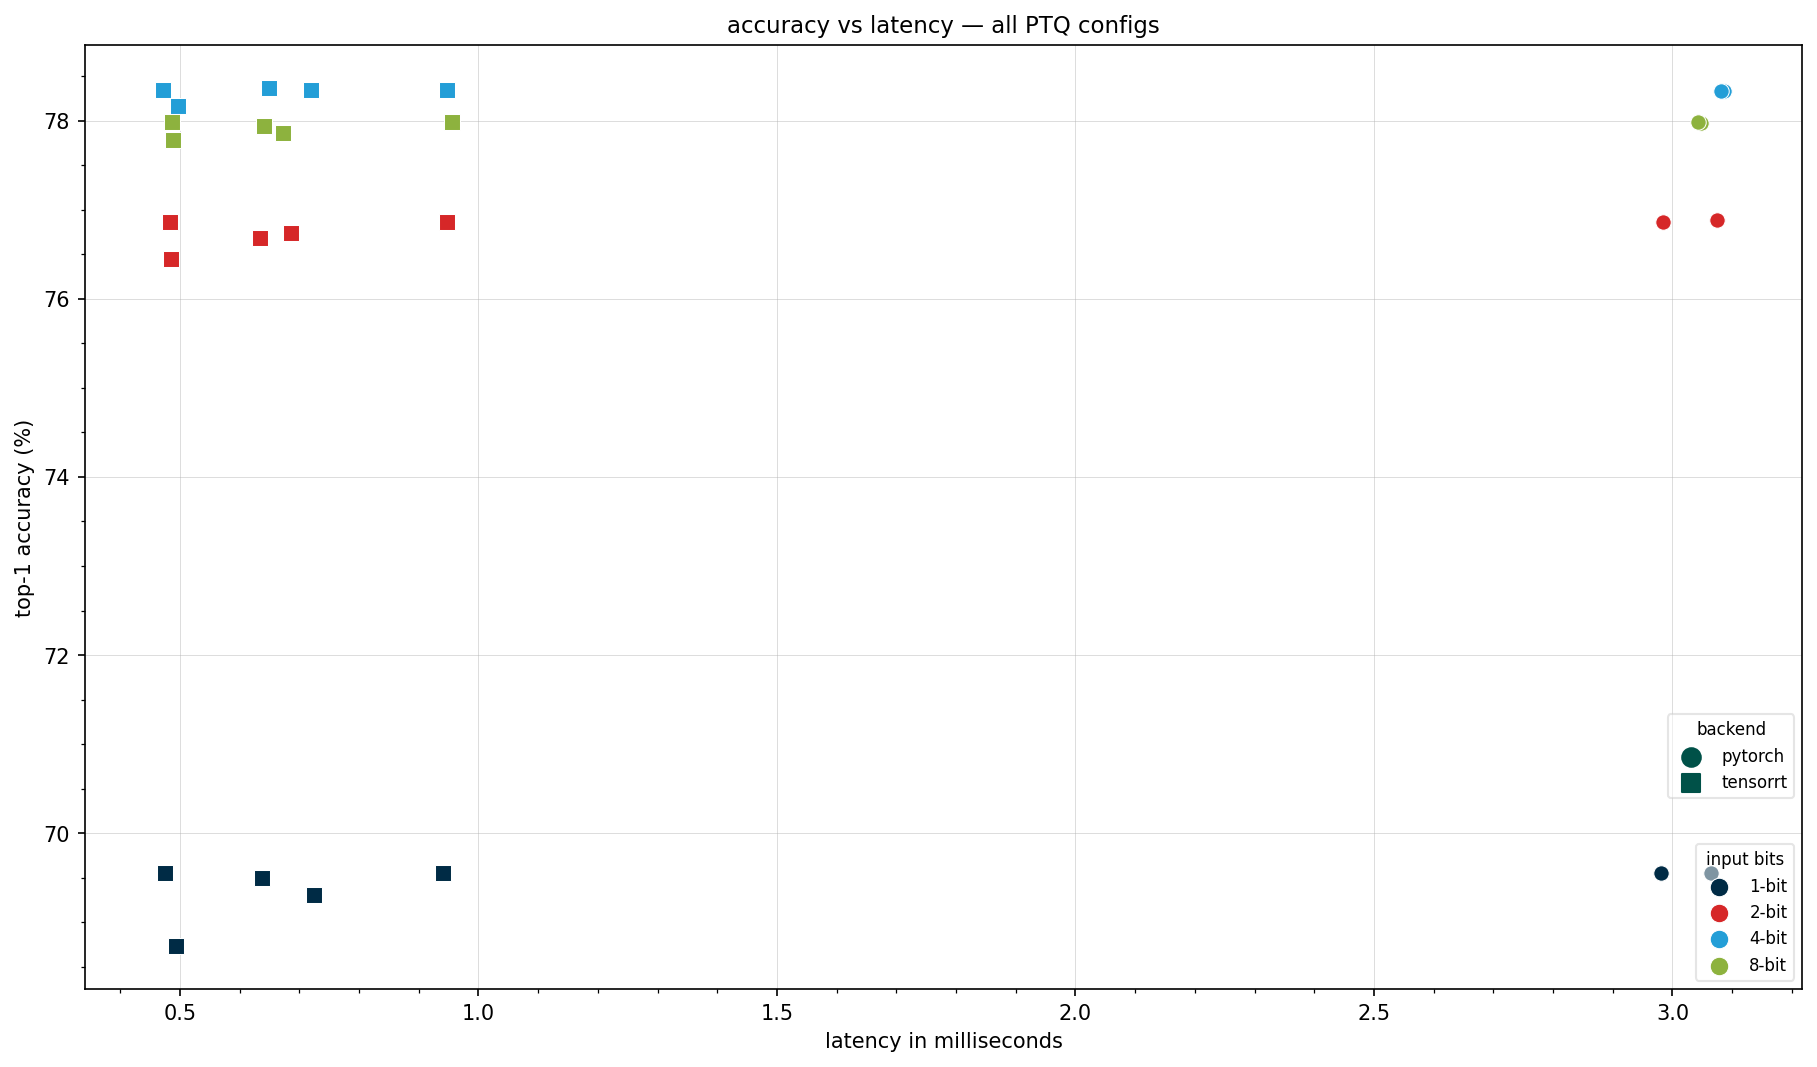

In [4]:
BACKEND_MARKERS = {"pytorch": "o", "tensorrt": "s"}
SCATTER_BIT_PALETTE = {1: "#002B45", 2: "#D62728", 4: "#239ED7", 8: "#8DB23E"}

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

for backend, bgrp in avg_ptq.groupby("backend"):
    marker = BACKEND_MARKERS.get(backend, "o")
    for _, row in bgrp.iterrows():
        bits = int(row["input_bits"])
        color = SCATTER_BIT_PALETTE.get(bits, "#7f7f7f")
        ax.scatter(row["latency_ms"], row["top1"],
                   color=color, marker=marker, s=55, edgecolors="white",
                   linewidths=0.5, zorder=3)

ax.set_xlabel("latency in milliseconds")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — all PTQ configs", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=55, edgecolors="white",
                linewidths=0.5, label=f"{b}-bit")
    for b, c in SCATTER_BIT_PALETTE.items()
    if b in avg_ptq["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits",
                    fontsize=8, title_fontsize=8, framealpha=0.5,
                    loc="lower right", markerscale=1.2)
ax.add_artist(legend1)

backend_handles = [
    plt.scatter([], [], color="#005148", marker=m, s=55, label=b)
    for b, m in BACKEND_MARKERS.items()
]
ax.legend(handles=backend_handles, title="backend",
          bbox_to_anchor=(1, 0.3), loc="upper right",
          fontsize=8, title_fontsize=8, framealpha=0.5, markerscale=1.2)

plt.show()

### Speedup vs baseline — all configs

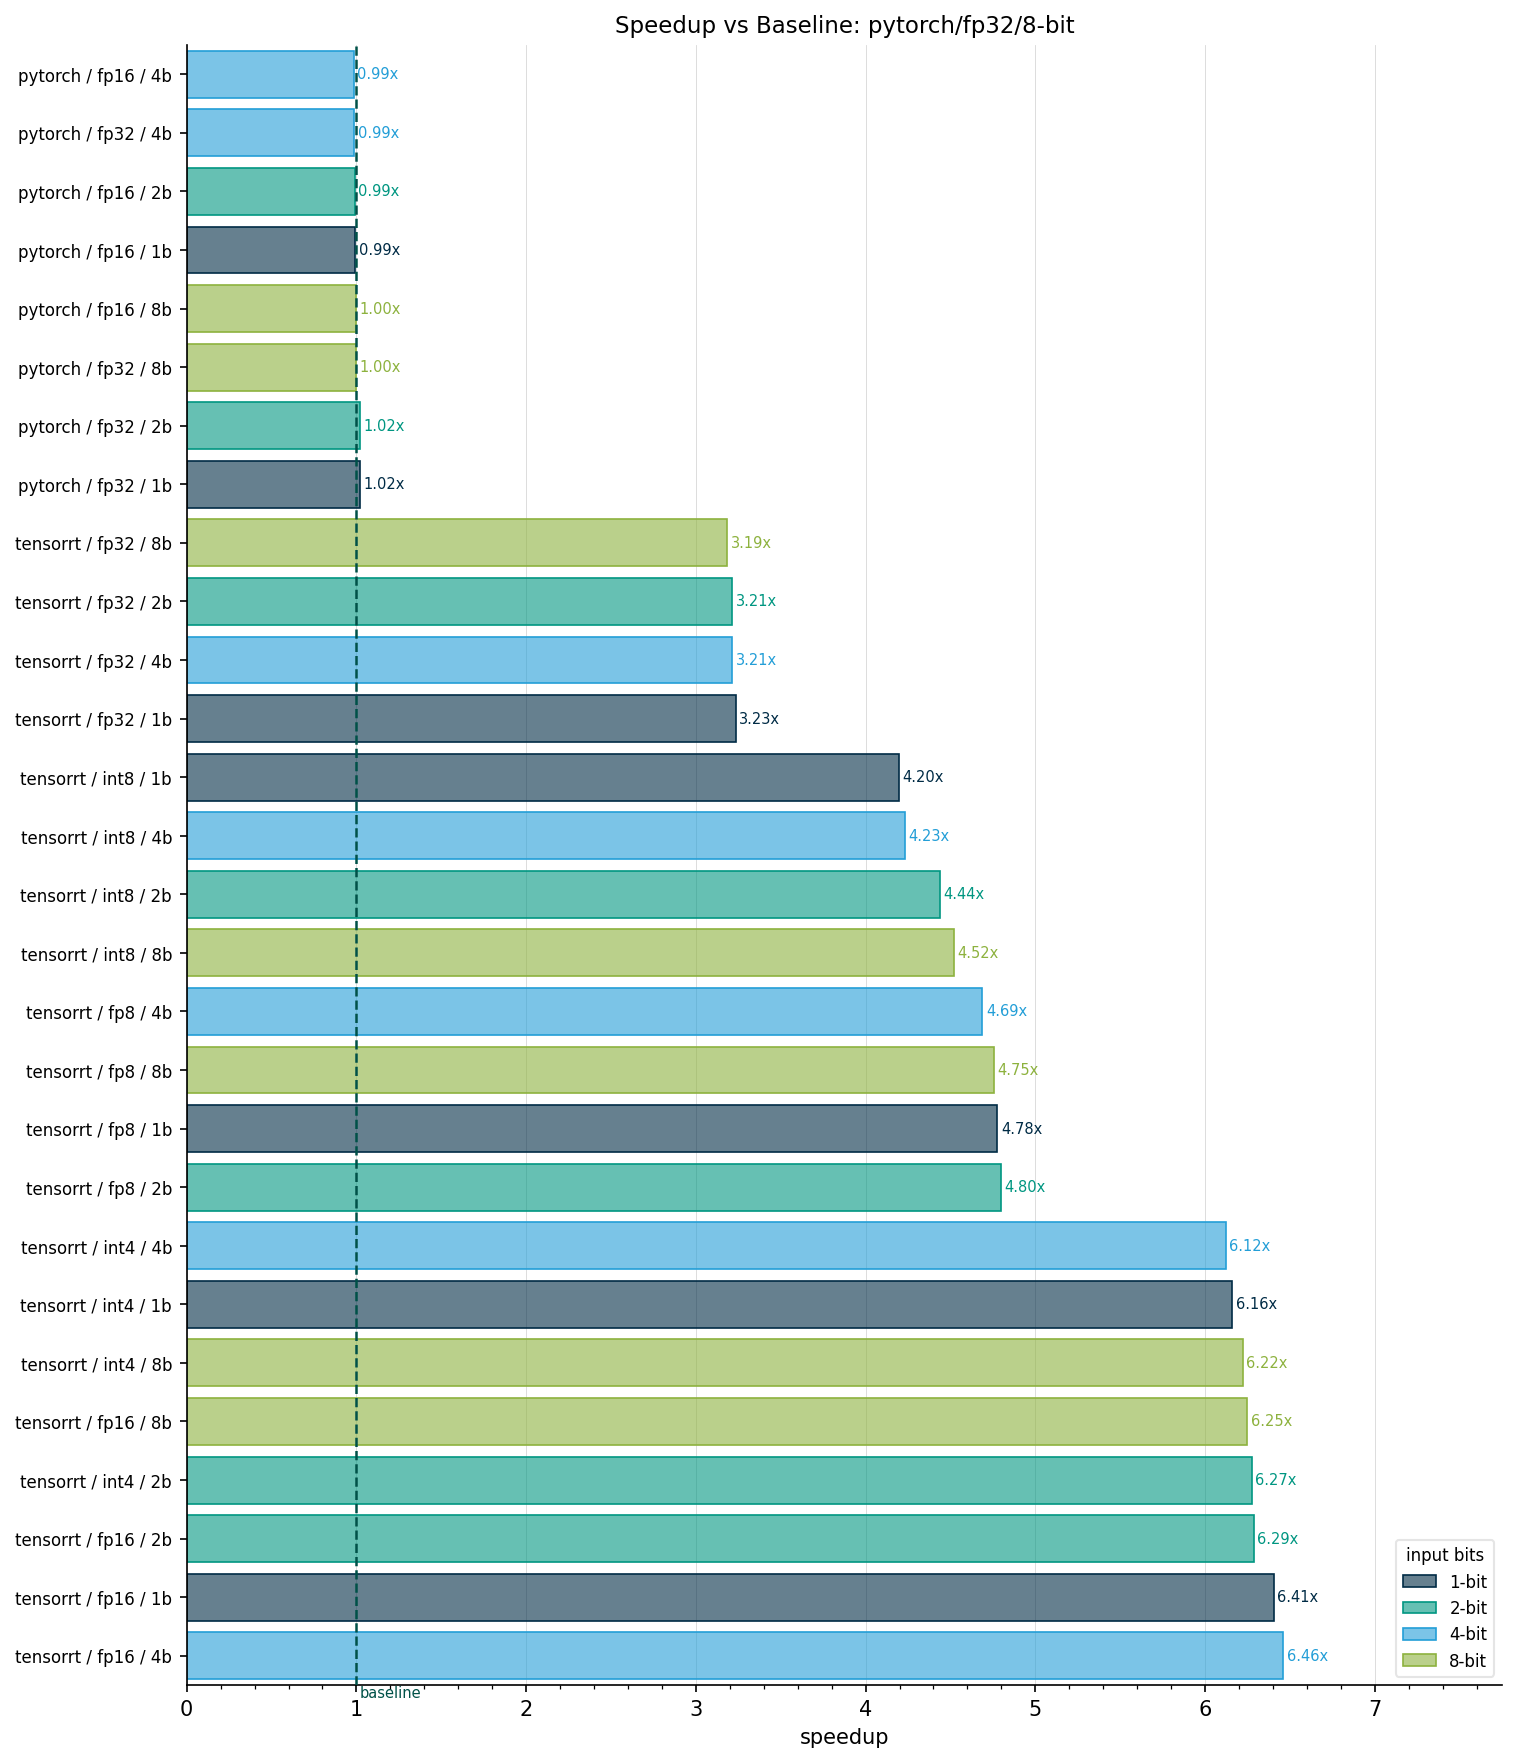

In [5]:
baseline_lat = avg_ptq[
    (avg_ptq["backend"] == "pytorch") &
    (avg_ptq["precision"] == "fp32") &
    (avg_ptq["input_bits"] == 8)
]["latency_ms"].values[0]

speedup = avg_ptq.copy()
speedup["speedup"] = baseline_lat / speedup["latency_ms"]
speedup["label"] = (speedup["backend"] + " / " +
                    speedup["precision"] + " / " +
                    speedup["input_bits"].astype(int).astype(str) + "b")

speedup = speedup.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup.iterrows()):
    bits = int(row["input_bits"])
    color = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}x",
            ha="left", va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(1.02, len(speedup) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(speedup)))
ax.set_yticklabels(speedup["label"], fontsize=8)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline: pytorch/fp32/8-bit", fontsize=11)
ax.set_xlim(0, speedup["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_bits = sorted(b for b in BIT_PALETTE if b in speedup["input_bits"].values)
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=BIT_PALETTE[b] + "99",
                  edgecolor=BIT_PALETTE[b], linewidth=0.8,
                  label=f"{b}-bit")
    for b in present_bits
]
ax.legend(handles=handles, title="input bits", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

### Accuracy drop vs baseline

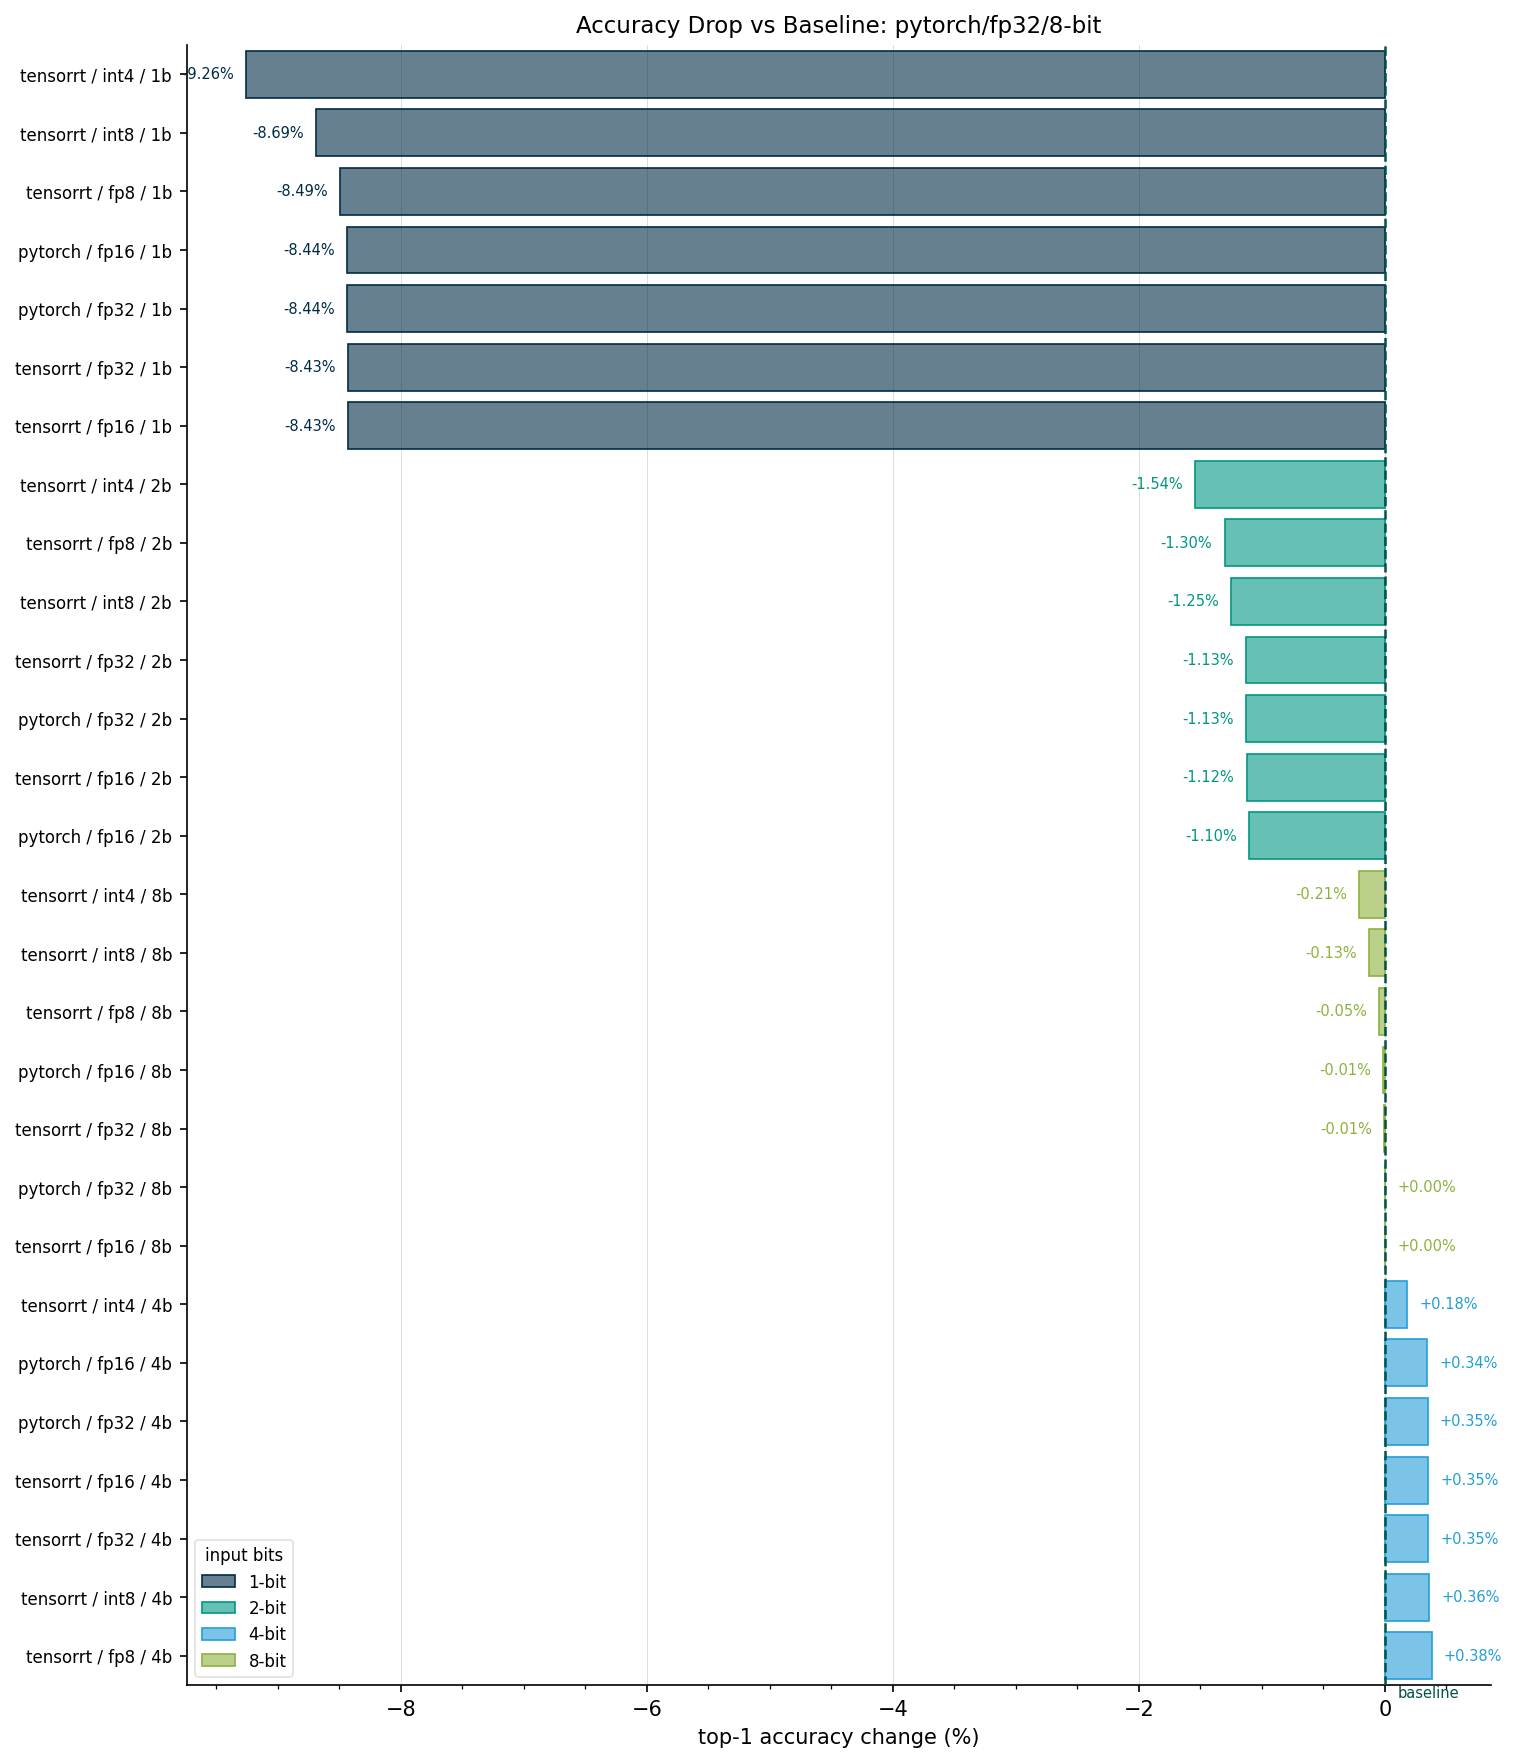

In [6]:
baseline_top1 = avg_ptq[
    (avg_ptq["backend"] == "pytorch") &
    (avg_ptq["precision"] == "fp32") &
    (avg_ptq["input_bits"] == 8)
]["top1"].values[0]

acc = avg_ptq.copy()
acc["acc_drop"] = acc["top1"] - baseline_top1
acc["label"] = (acc["backend"] + " / " +
                acc["precision"] + " / " +
                acc["input_bits"].astype(int).astype(str) + "b")

acc = acc.sort_values("acc_drop", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(acc) * 0.38 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(acc.iterrows()):
    bits = int(row["input_bits"])
    color = BIT_PALETTE.get(bits, "#7f7f7f")
    ax.barh(yi, row["acc_drop"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    sign = "+" if row["acc_drop"] >= 0 else ""
    offset = 0.1 if row["acc_drop"] >= 0 else -0.1
    ax.text(row["acc_drop"] + offset, yi,
            f"{sign}{row['acc_drop']:.2f}%",
            ha="left" if row["acc_drop"] >= 0 else "right",
            va="center", fontsize=7, color=color, zorder=4)

ax.axvline(x=0.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(0.1, len(acc) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(acc)))
ax.set_yticklabels(acc["label"], fontsize=8)
ax.set_xlabel("top-1 accuracy change (%)")
ax.set_title("Accuracy Drop vs Baseline: pytorch/fp32/8-bit", fontsize=11)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(acc) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_bits = sorted(b for b in BIT_PALETTE if b in acc["input_bits"].values)
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=BIT_PALETTE[b] + "99",
                  edgecolor=BIT_PALETTE[b], linewidth=0.8,
                  label=f"{b}-bit")
    for b in present_bits
]
ax.legend(handles=handles, title="input bits", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower left")

plt.show()

### QAT INT4 vs INT8 vs FP32

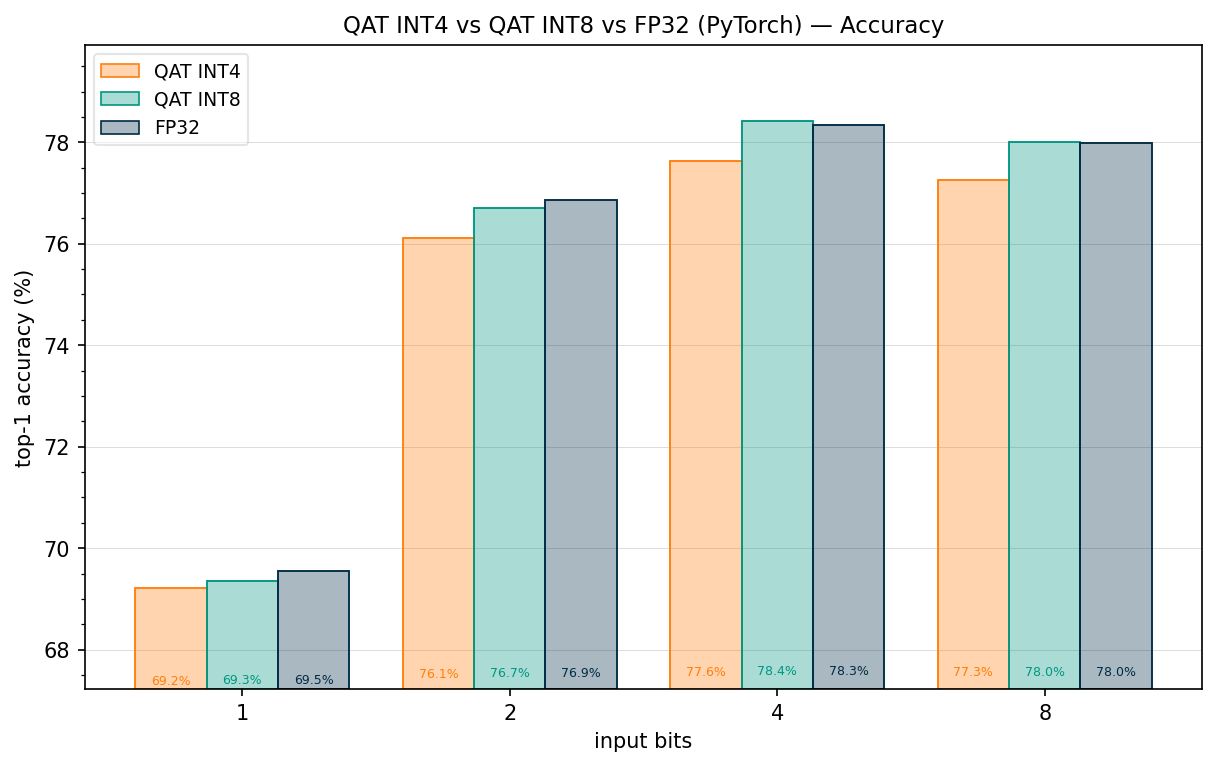

In [7]:
qat_i4 = avg_qat[avg_qat["precision"] == "int4"].sort_values("input_bits").reset_index(drop=True)
qat_i8_pt = avg_qat[
    (avg_qat["precision"] == "int8") & (avg_qat["backend"] == "pytorch")
].sort_values("input_bits").reset_index(drop=True)
pt_fp32 = avg_ptq[
    (avg_ptq["backend"] == "pytorch") & (avg_ptq["precision"] == "fp32")
].sort_values("input_bits").reset_index(drop=True)

groups = [
    ("QAT INT4", qat_i4, QAT_PALETTE["qat_int4"]),
    ("QAT INT8", qat_i8_pt, QAT_PALETTE["qat_int8"]),
    ("FP32", pt_fp32, PREC_PALETTE["fp32"]),
]

bits_list = sorted(pt_fp32["input_bits"].astype(int).unique())
x_pos = np.arange(len(bits_list))
n_grp = len(groups)
width = 0.8 / n_grp

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

all_vals = pd.concat([g[1]["top1"] for g in groups])
y_bottom = all_vals.min() - 2
y_top = all_vals.max() + 1.5
ax.set_ylim(y_bottom, y_top)

for gi, (label, grp, color) in enumerate(groups):
    offset = (gi - (n_grp - 1) / 2) * width
    for i, (_, row) in enumerate(grp.iterrows()):
        ax.bar(x_pos[i] + offset, row["top1"] - y_bottom, width,
               bottom=y_bottom,
               color=color + "55", edgecolor=color, linewidth=0.9, zorder=2)
        ax.text(x_pos[i] + offset, y_bottom + (row["top1"] - y_bottom) * 0.02,
                f"{row['top1']:.1f}%", ha="center", va="bottom",
                fontsize=6, color=color, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(b) for b in bits_list])
ax.set_xlabel("input bits")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("QAT INT4 vs QAT INT8 vs FP32 (PyTorch) — Accuracy", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=c + "55", edgecolor=c,
                  linewidth=0.8, label=lbl)
    for lbl, _, c in groups
]
ax.legend(handles=handles, fontsize=9, framealpha=0.5, loc="upper left")

plt.show()

### QAT INT4 vs INT8 with deltas

In [ ]:
groups = [
    ("QAT INT4", qat_i4, QAT_PALETTE["qat_int4"]),
    ("QAT INT8", qat_i8_pt, QAT_PALETTE["qat_int8"]),
]

bits_list = sorted(qat_i4["input_bits"].astype(int).unique())
x_pos = np.arange(len(bits_list))
n_grp = len(groups)
width = 0.8 / n_grp

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

all_vals = pd.concat([g[1]["top1"] for g in groups])
y_bottom = all_vals.min() - 2
y_top = all_vals.max() + 1.5
ax.set_ylim(y_bottom, y_top)

for gi, (label, grp, color) in enumerate(groups):
    offset = (gi - (n_grp - 1) / 2) * width
    for i, (_, row) in enumerate(grp.iterrows()):
        ax.bar(x_pos[i] + offset, row["top1"] - y_bottom, width,
               bottom=y_bottom,
               color=color + "55", edgecolor=color, linewidth=0.9, zorder=2)
        ax.text(x_pos[i] + offset, y_bottom + (row["top1"] - y_bottom) * 0.02,
                f"{row['top1']:.1f}%", ha="center", va="bottom",
                fontsize=6, color=color, zorder=3)

for i in range(len(bits_list)):
    i4_val = qat_i4.iloc[i]["top1"]
    i8_val = qat_i8_pt.iloc[i]["top1"]
    delta = i4_val - i8_val
    ax.text(x_pos[i], min(i4_val, i8_val) - 0.4,
            f"Δ {delta:.2f}",
            ha="center", va="top", fontsize=7, fontweight="bold",
            color="#D62728", zorder=4)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(b) for b in bits_list])
ax.set_xlabel("input bits")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("QAT INT4 vs QAT INT8 (PyTorch) — Accuracy", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=c + "55", edgecolor=c,
                  linewidth=0.8, label=lbl)
    for lbl, _, c in groups
]
ax.legend(handles=handles, fontsize=9, framealpha=0.5, loc="upper left")

plt.show()

### TensorRT latency — all precisions

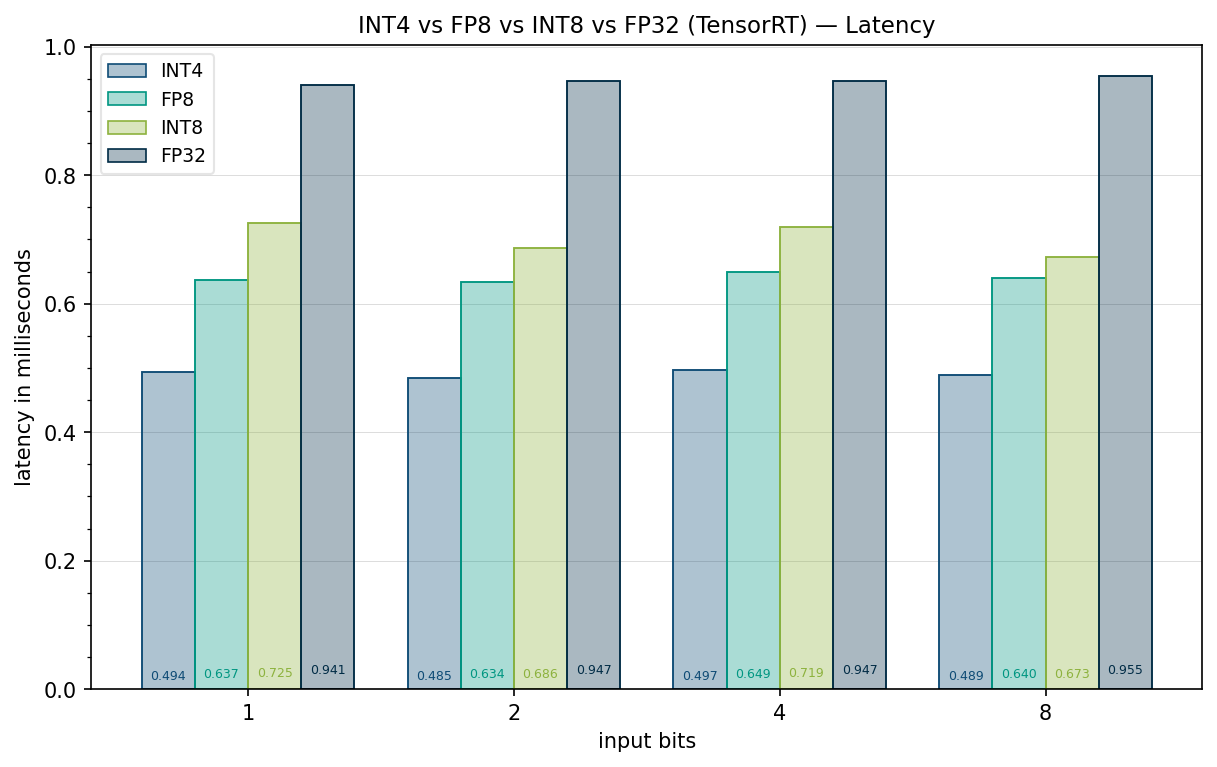

In [9]:
prec_order = ["int4", "fp8", "int8", "fp32"]
trt_groups = []
for prec in prec_order:
    grp = avg_ptq[
        (avg_ptq["backend"] == "tensorrt") & (avg_ptq["precision"] == prec)
    ].sort_values("input_bits").reset_index(drop=True)
    trt_groups.append((prec.upper(), grp, PREC_PALETTE[prec]))

bits_list = sorted(trt_groups[0][1]["input_bits"].astype(int).unique())
x_pos = np.arange(len(bits_list))
n_grp = len(trt_groups)
width = 0.8 / n_grp

fig, ax = plt.subplots(figsize=(8, 5), constrained_layout=True)

for gi, (label, grp, color) in enumerate(trt_groups):
    offset = (gi - (n_grp - 1) / 2) * width
    for i, (_, row) in enumerate(grp.iterrows()):
        ax.bar(x_pos[i] + offset, row["latency_ms"], width,
               color=color + "55", edgecolor=color, linewidth=0.9, zorder=2)
        ax.text(x_pos[i] + offset, row["latency_ms"] * 0.02,
                f"{row['latency_ms']:.3f}", ha="center", va="bottom",
                fontsize=6, color=color, zorder=3)

ax.set_xticks(x_pos)
ax.set_xticklabels([str(b) for b in bits_list])
ax.set_xlabel("input bits")
ax.set_ylabel("latency in milliseconds")
ax.set_title("INT4 vs FP8 vs INT8 vs FP32 (TensorRT) — Latency", fontsize=11)
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

handles = [
    plt.Rectangle((0, 0), 1, 1, facecolor=c + "55", edgecolor=c,
                  linewidth=0.8, label=lbl)
    for lbl, _, c in trt_groups
]
ax.legend(handles=handles, fontsize=9, framealpha=0.5, loc="upper left")

plt.show()

### Speedup — 8-bit input

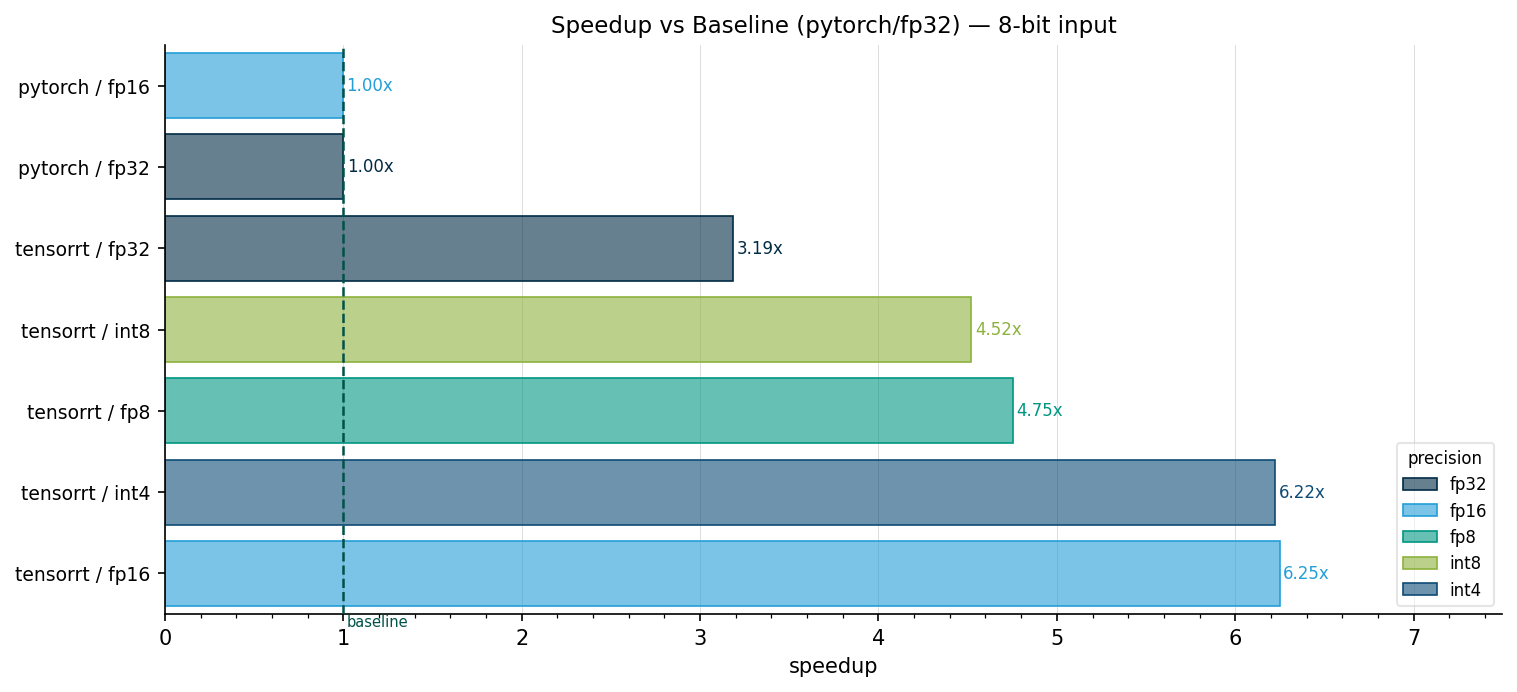

In [10]:
PREC_ORDER = ["int4", "int8", "fp8", "fp16", "fp32"]

speedup_8 = avg_ptq[avg_ptq["input_bits"] == 8].copy()
speedup_8["speedup"] = baseline_lat / speedup_8["latency_ms"]
speedup_8["label"] = speedup_8["backend"] + " / " + speedup_8["precision"]
speedup_8 = speedup_8.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup_8) * 0.5 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup_8.iterrows()):
    color = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}x",
            ha="left", va="center", fontsize=8, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(1.02, len(speedup_8) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(speedup_8)))
ax.set_yticklabels(speedup_8["label"], fontsize=9)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline (pytorch/fp32) — 8-bit input", fontsize=11)
ax.set_xlim(0, speedup_8["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup_8) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_precs = [p for p in PREC_PALETTE if p in speedup_8["precision"].values]
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=PREC_PALETTE[p] + "99",
                  edgecolor=PREC_PALETTE[p], linewidth=0.8, label=p)
    for p in present_precs
]
ax.legend(handles=handles, title="precision", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

### Speedup — 1-bit input

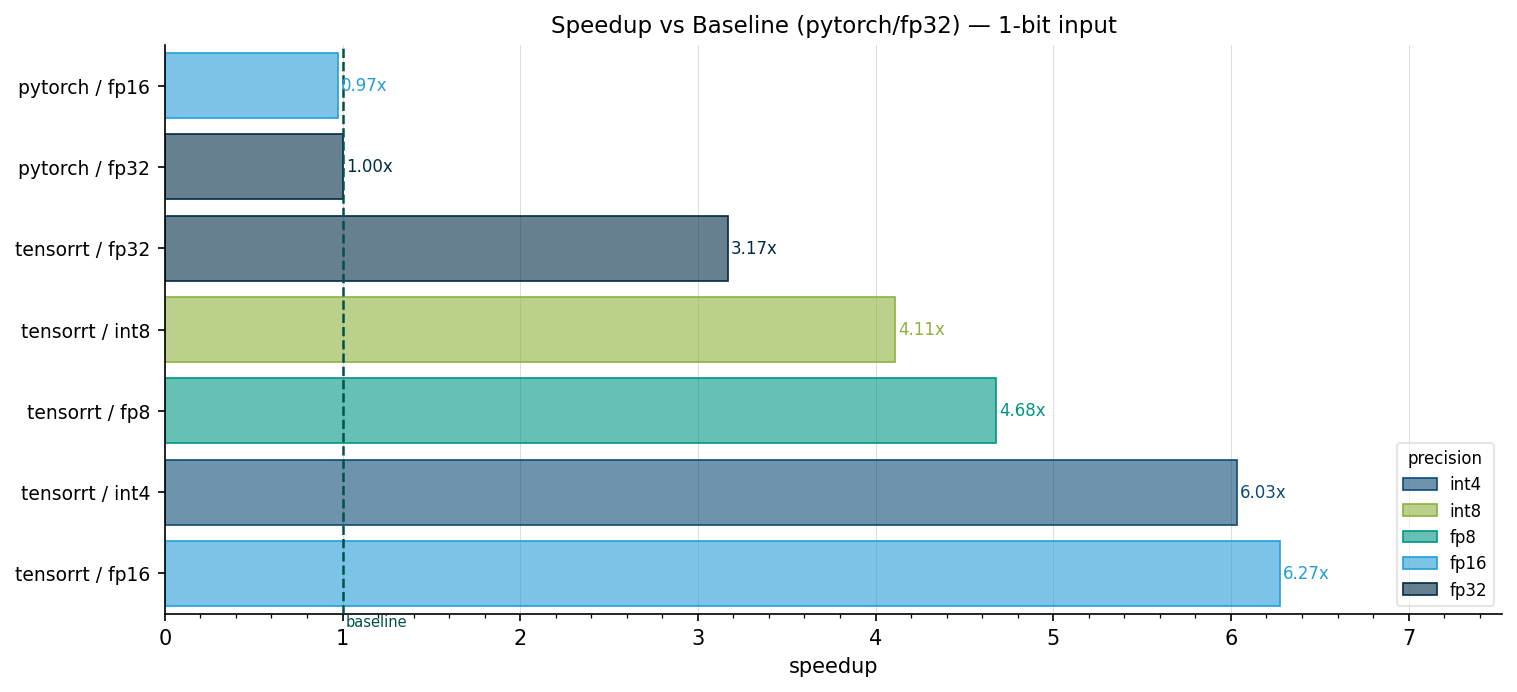

In [11]:
baseline_lat_1b = avg_ptq[
    (avg_ptq["backend"] == "pytorch") &
    (avg_ptq["precision"] == "fp32") &
    (avg_ptq["input_bits"] == 1)
]["latency_ms"].values[0]

speedup_1 = avg_ptq[avg_ptq["input_bits"] == 1].copy()
speedup_1["speedup"] = baseline_lat_1b / speedup_1["latency_ms"]
speedup_1["label"] = speedup_1["backend"] + " / " + speedup_1["precision"]
speedup_1 = speedup_1.sort_values("speedup", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, len(speedup_1) * 0.5 + 1.0), constrained_layout=True)

for yi, (_, row) in enumerate(speedup_1.iterrows()):
    color = PREC_PALETTE.get(row["precision"], "#7f7f7f")
    ax.barh(yi, row["speedup"],
            color=color + "99", edgecolor=color,
            linewidth=0.8, height=0.8, zorder=2)
    ax.text(row["speedup"] + 0.02, yi,
            f"{row['speedup']:.2f}x",
            ha="left", va="center", fontsize=8, color=color, zorder=4)

ax.axvline(x=1.0, color="#005148", linewidth=1.2,
           linestyle="--", zorder=3)
ax.text(1.02, len(speedup_1) - 0.5, "baseline",
        ha="left", va="top", fontsize=7, color="#005148")

ax.set_yticks(np.arange(len(speedup_1)))
ax.set_yticklabels(speedup_1["label"], fontsize=9)
ax.set_xlabel("speedup")
ax.set_title("Speedup vs Baseline (pytorch/fp32) — 1-bit input", fontsize=11)
ax.set_xlim(0, speedup_1["speedup"].max() * 1.2)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(axis="x", linewidth=0.4, alpha=0.5, zorder=1)
ax.set_ylim(-0.5, len(speedup_1) - 0.5)
ax.invert_yaxis()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

present_precs = [p for p in PREC_ORDER if p in speedup_1["precision"].values]
handles = [
    plt.Rectangle((0, 0), 1, 1,
                  facecolor=PREC_PALETTE[p] + "99",
                  edgecolor=PREC_PALETTE[p], linewidth=0.8, label=p)
    for p in present_precs
]
ax.legend(handles=handles, title="precision", fontsize=8,
          title_fontsize=8, framealpha=0.5, loc="lower right")

plt.show()

### TensorRT precision vs latency

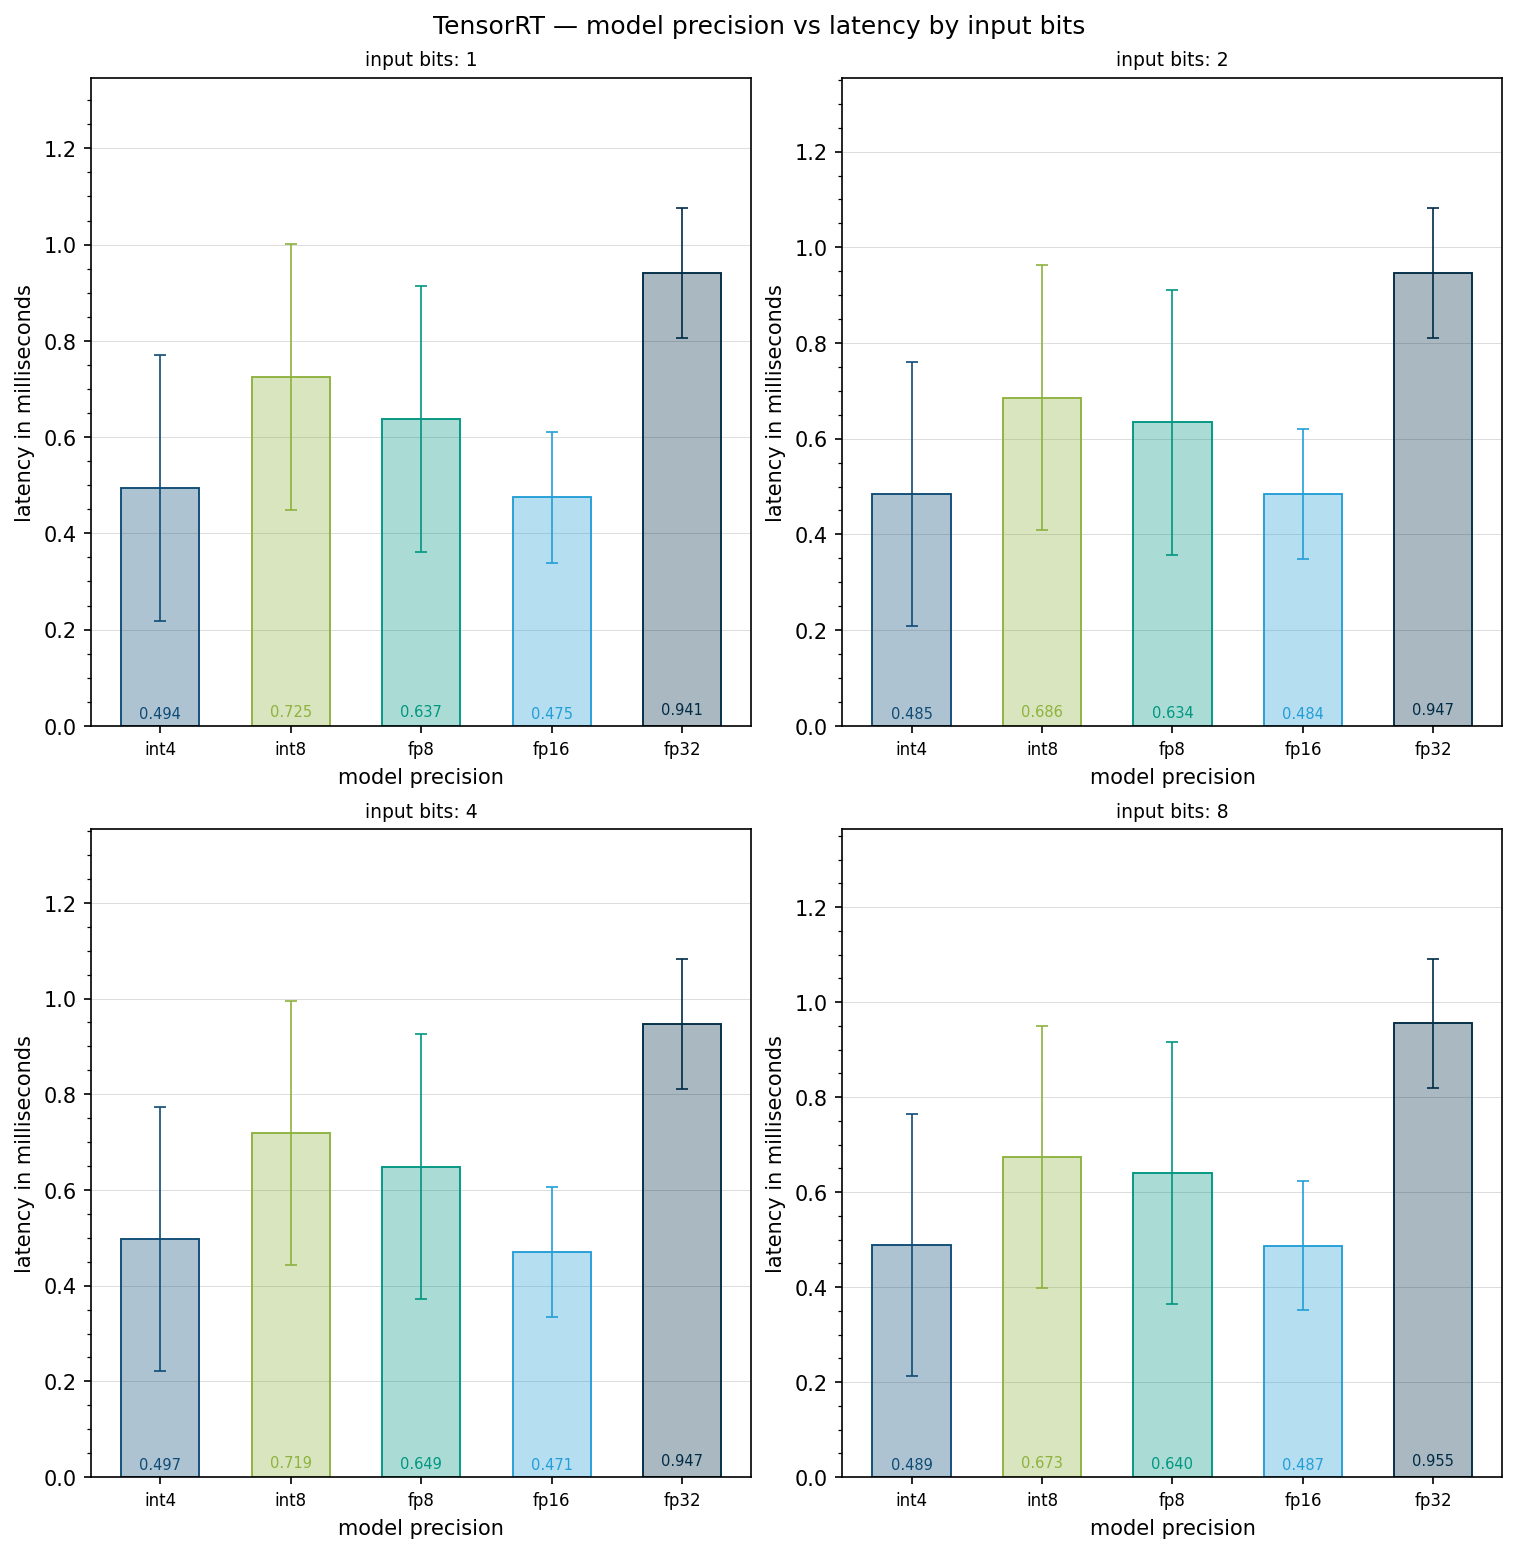

In [12]:
trt = avg_ptq[avg_ptq["backend"] == "tensorrt"].copy()
trt["precision"] = pd.Categorical(trt["precision"], categories=PREC_ORDER, ordered=True)
active_bits = sorted(trt["input_bits"].astype(int).unique())

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
fig.suptitle("TensorRT — model precision vs latency by input bits", fontsize=12, y=1.02)

for ax, bits in zip(axes.flatten(), active_bits):
    grp = trt[trt["input_bits"] == bits].sort_values("precision").reset_index(drop=True)

    x_pos = np.arange(len(grp))
    for xi, (_, row) in enumerate(grp.iterrows()):
        c = PREC_PALETTE.get(row["precision"], "#7f7f7f")
        ax.bar(xi, row["latency_ms"], color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.errorbar(xi, row["latency_ms"], yerr=row["latency_std"],
                    fmt="none", ecolor=c, **eb_kw)
        ax.text(xi, row["latency_ms"] * 0.02, f"{row['latency_ms']:.3f}",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(grp["precision"].tolist(), fontsize=8)
    ax.set_xlabel("model precision")
    ax.set_ylabel("latency in milliseconds")
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.set_ylim(0, (grp["latency_ms"] + grp["latency_std"]).max() * 1.25)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

plt.show()

### TensorRT precision vs accuracy

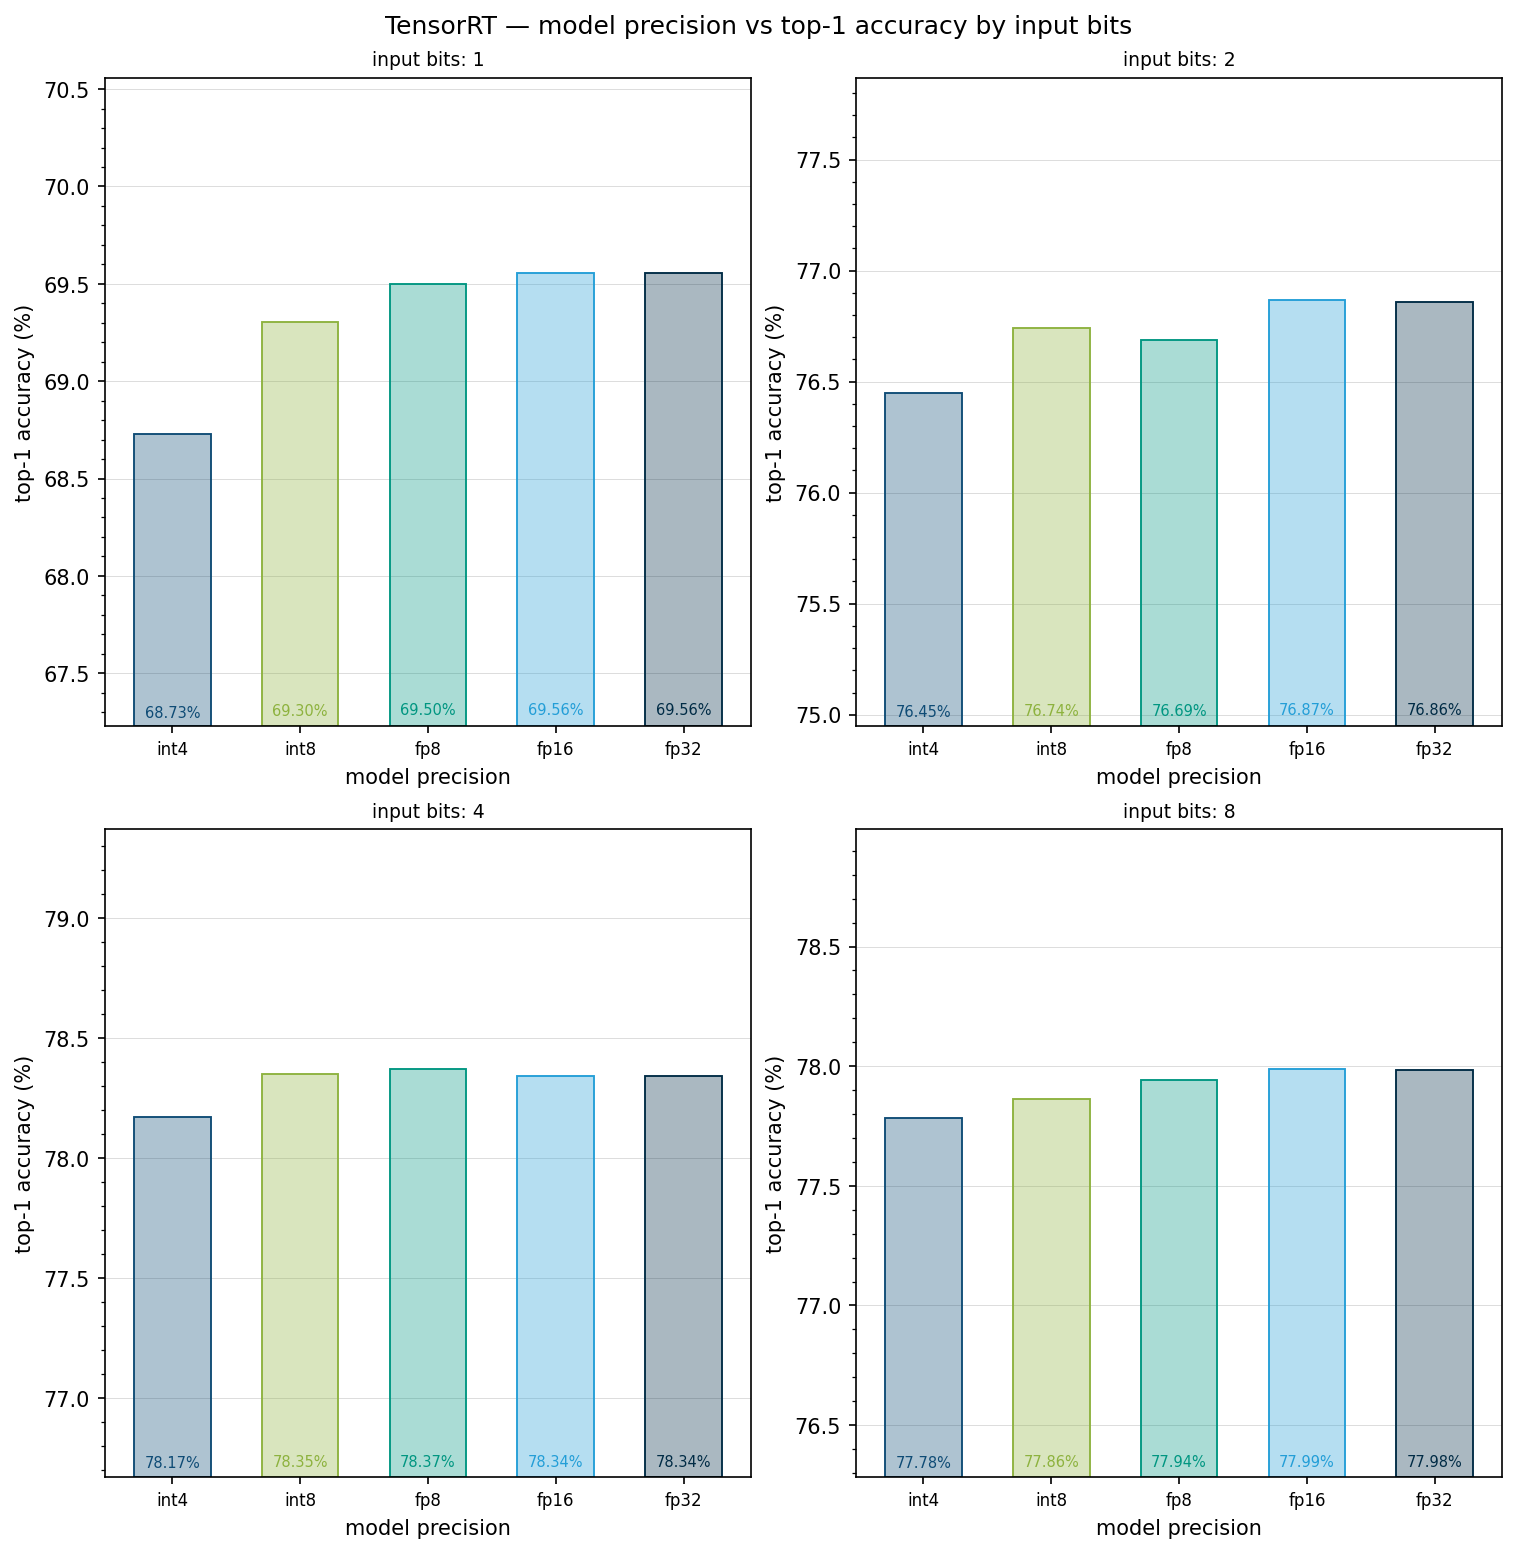

In [13]:
trt_acc = avg_ptq[avg_ptq["backend"] == "tensorrt"].copy()
trt_acc["precision"] = pd.Categorical(trt_acc["precision"], categories=PREC_ORDER, ordered=True)
active_bits = sorted(trt_acc["input_bits"].astype(int).unique())

fig, axes = plt.subplots(2, 2, figsize=(10, 10), constrained_layout=True)
fig.suptitle("TensorRT — model precision vs top-1 accuracy by input bits", fontsize=12, y=1.02)

for ax, bits in zip(axes.flatten(), active_bits):
    grp = trt_acc[trt_acc["input_bits"] == bits].sort_values("precision").reset_index(drop=True)

    y_bottom = grp["top1"].min() - 1.5
    y_top = grp["top1"].max() + 1.0
    ax.set_ylim(y_bottom, y_top)

    x_pos = np.arange(len(grp))
    for xi, (_, row) in enumerate(grp.iterrows()):
        c = PREC_PALETTE.get(row["precision"], "#7f7f7f")
        ax.bar(xi, row["top1"] - y_bottom, bottom=y_bottom,
               color=c + "55", edgecolor=c,
               linewidth=0.9, width=0.6, zorder=2)
        ax.text(xi, y_bottom + (row["top1"] - y_bottom) * 0.02,
                f"{row['top1']:.2f}%",
                ha="center", va="bottom", fontsize=7, color=c, zorder=3)

    ax.set_xticks(x_pos)
    ax.set_xticklabels(grp["precision"].tolist(), fontsize=8)
    ax.set_xlabel("model precision")
    ax.set_ylabel("top-1 accuracy (%)")
    ax.set_title(f"input bits: {bits}", fontsize=9)
    ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
    ax.grid(axis="y", linewidth=0.4, alpha=0.5, zorder=1)

plt.show()

### Zoomed scatter — best configs

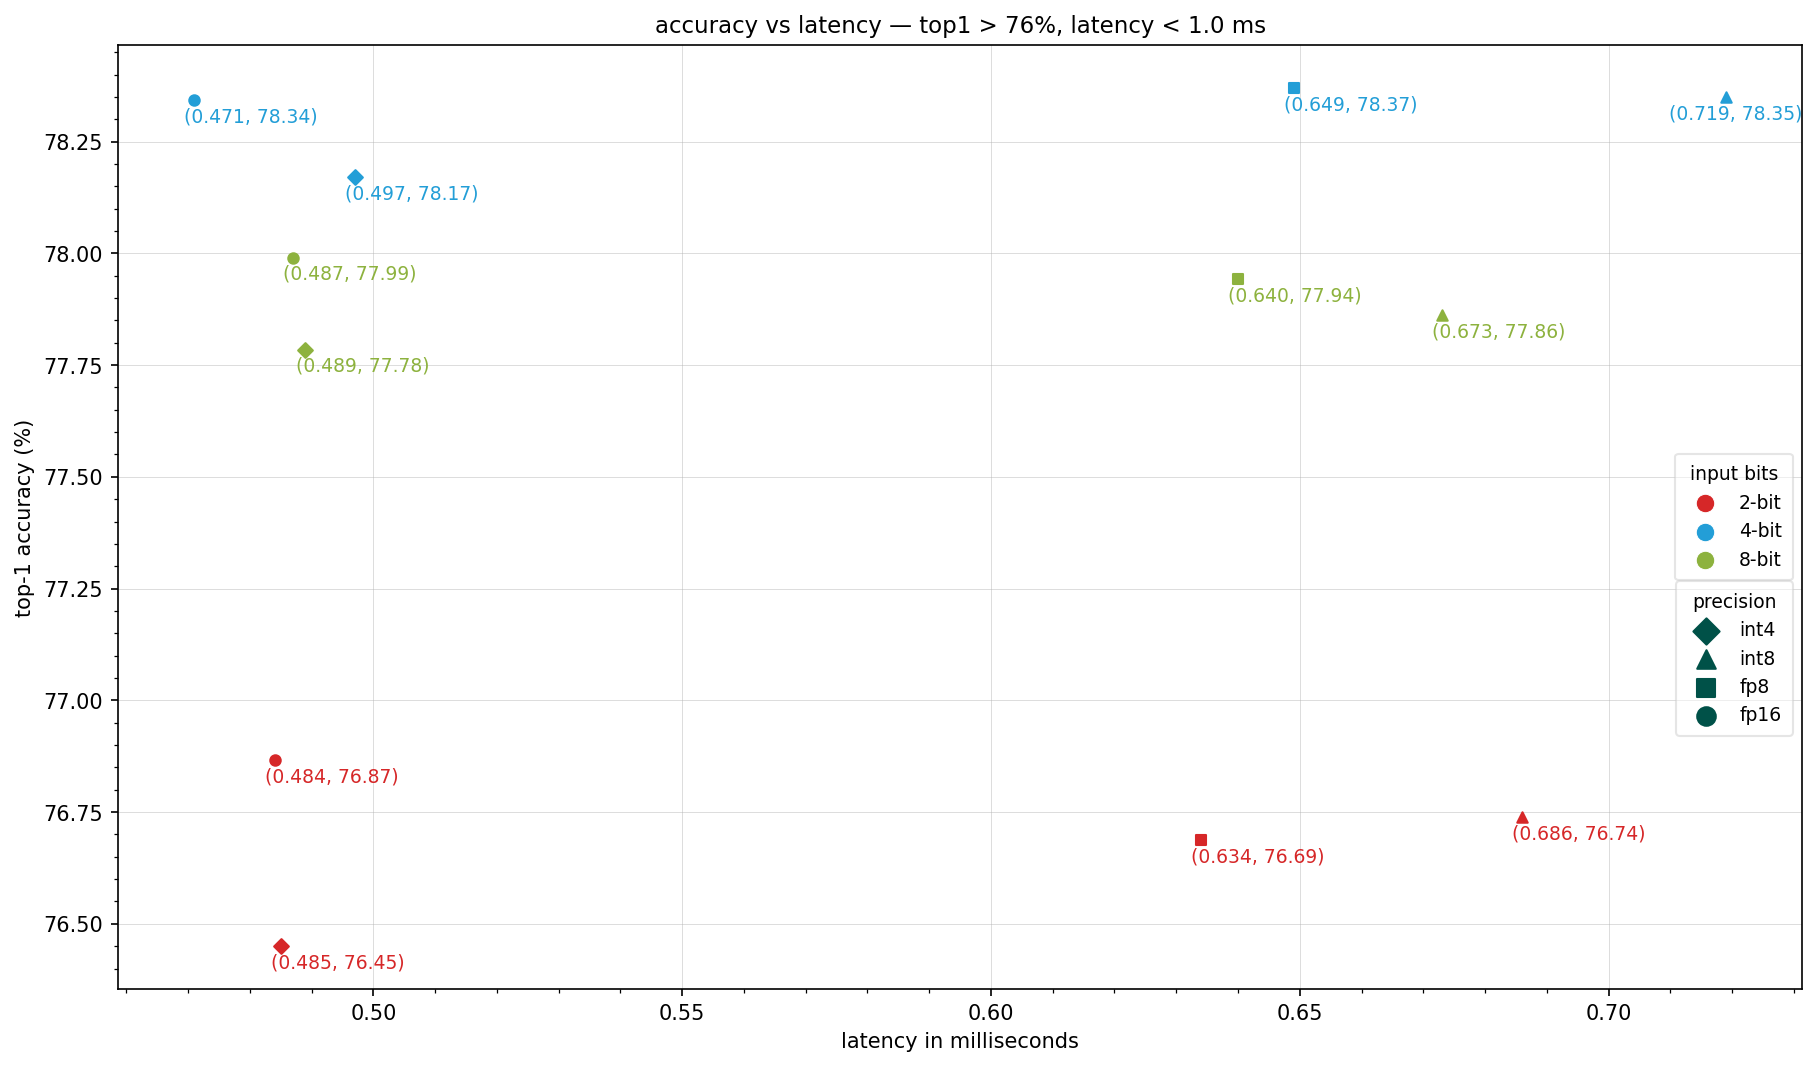

In [14]:
from adjustText import adjust_text

PREC_MARKERS = {"int4": "D", "int8": "^", "fp8": "s", "fp16": "o", "fp32": "P"}

filtered = avg_ptq[
    (avg_ptq["top1"] > 76) & (avg_ptq["latency_ms"] < 1.0)
    & (avg_ptq["precision"] != "fp32")
]

fig, ax = plt.subplots(figsize=(12, 7), constrained_layout=True)

texts = []
for _, row in filtered.iterrows():
    bits = int(row["input_bits"])
    color = SCATTER_BIT_PALETTE.get(bits, "#7f7f7f")
    marker = PREC_MARKERS.get(row["precision"], "o")
    ax.scatter(row["latency_ms"], row["top1"],
               marker=marker, color=color, s=25, zorder=3)
    texts.append(ax.text(
        row["latency_ms"], row["top1"] - 0.01,
        f"({row['latency_ms']:.3f}, {row['top1']:.2f})",
        fontsize=9, color=color, ha="center", va="top",
    ))

ax.set_xlabel("latency in milliseconds")
ax.set_ylabel("top-1 accuracy (%)")
ax.set_title("accuracy vs latency — top1 > 76%, latency < 1.0 ms", fontsize=11)
ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.grid(linewidth=0.4, alpha=0.5, zorder=1)

adjust_text(
    texts, ax=ax,
    only_move={"text": "y", "static": "y", "explode": "y"},
    expand_points=(1.4, 2.0),
    expand_text=(1.2, 1.6),
)

legend_kw = dict(fontsize=9, title_fontsize=9, framealpha=0.5,
                 markerscale=1.2, handletextpad=0.8, borderpad=0.6)

bits_handles = [
    plt.scatter([], [], color=c, marker="o", s=55, edgecolors="white",
                linewidths=0.5, label=f"{b}-bit")
    for b, c in SCATTER_BIT_PALETTE.items()
    if b in filtered["input_bits"].values
]
legend1 = ax.legend(handles=bits_handles, title="input bits",
                    loc="center right", **legend_kw)
ax.add_artist(legend1)

prec_handles = [
    plt.scatter([], [], color="#005148", marker=PREC_MARKERS[p], s=55, label=p)
    for p in PREC_ORDER
    if p in filtered["precision"].values
]
ax.legend(handles=prec_handles, title="precision",
          bbox_to_anchor=(1, 0.35), loc="center right", **legend_kw)

plt.show()